In [ ]:
### 1. Project Title
"""# Customer Segmentation Analysis for Online Retail"""

### 2. Introduction
"""This project aims to perform customer segmentation using the Online Retail dataset. Customer segmentation is a crucial marketing strategy that divides a broad customer base into subgroups of consumers who have common needs and preferences. By understanding these segments, businesses can tailor their marketing efforts, product development, and customer service to better meet the needs of different customer groups, ultimately leading to increased customer satisfaction and profitability."""

### 3. Business Objective
"""The primary business objective is to identify distinct customer segments within the Online Retail dataset. This segmentation will enable the business to:
- Develop targeted marketing campaigns.
- Optimize product recommendations.
- Improve customer retention strategies.
- Allocate resources more efficiently based on customer value and behavior."""

### 4. Dataset Description
"""The dataset 'Online Retail.xlsx' contains transactional data from a UK-based online retail store. It includes information about sales transactions occurring between 01/12/2009 and 09/12/2011. Key features include InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country."""

### 5. Import Libraries
# Import necessary libraries for data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

### 6. Load Dataset
# Load the 'Online Retail.xlsx' dataset into a pandas DataFrame
try:
    df = pd.read_excel('/content/Online Retail.xlsx')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'Online Retail.xlsx' not found. Please ensure the file is uploaded to '/content/'.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors in subsequent steps

# Display the first few rows of the DataFrame to understand its structure
print("\n### 7. Display First Rows")
if not df.empty:
    print(df.head())
else:
    print("DataFrame is empty, cannot display head.")

# Get the shape (number of rows and columns) of the DataFrame
print("\n### 8. Shape")
if not df.empty:
    print(f"DataFrame shape: {df.shape}")
else:
    print("DataFrame is empty, cannot determine shape.")

# Display the data types of each column
print("\n### 9. Data Types")
if not df.empty:
    print(df.info())
else:
    print("DataFrame is empty, cannot display data types.")

# Check for missing values in each column
print("\n### 10. Missing Values")
if not df.empty:
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
    print(missing_df[missing_df['Missing Count'] > 0])
else:
    print("DataFrame is empty, cannot check for missing values.")

# Check for duplicate rows
print("\n### 11. Duplicate Values")
if not df.empty:
    duplicate_rows = df.duplicated().sum()
    print(f"Number of duplicate rows: {duplicate_rows}")
    if duplicate_rows > 0:
        print("First 5 duplicate rows:")
        print(df[df.duplicated(keep=False)].head())
else:
    print("DataFrame is empty, cannot check for duplicate values.")

### 12. Data Quality Report
"""This section summarizes the initial data quality check. We have identified the shape, data types, and presence of missing and duplicate values.
- **Missing Values**: 'Description' and 'CustomerID' columns have missing values.
- **Duplicate Values**: There are a significant number of duplicate rows.

These issues will need to be addressed in subsequent data cleaning steps to ensure the accuracy and reliability of our analysis."""

Libraries imported successfully.
Dataset loaded successfully.

### 7. Display First Rows
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

### 8. Shape
DataFrame shape: (541909, 8)

### 9. Data Types
<class 'pandas.core.frame.DataFrame'>


"This section summarizes the initial data quality check. We have identified the shape, data types, and presence of missing and duplicate values.  \n- **Missing Values**: 'Description' and 'CustomerID' columns have missing values.  \n- **Duplicate Values**: There are a significant number of duplicate rows.  \n\nThese issues will need to be addressed in subsequent data cleaning steps to ensure the accuracy and reliability of our analysis."

### 13. Data Cleaning - Handle Missing Values

Based on our initial data quality report, the `CustomerID` column has a significant number of missing values (approximately 25%). Since `CustomerID` is fundamental for customer segmentation, we will remove rows where this value is missing. The `Description` column also has a small number of missing values, but these rows will be dropped implicitly when we filter out rows with missing `CustomerID`.

In [ ]:
# Remove rows with missing CustomerID
df_cleaned = df.dropna(subset=['CustomerID'])

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after removing missing CustomerID: {df_cleaned.shape}")

# Verify that there are no more missing CustomerIDs
print("\nMissing values after cleaning CustomerID:")
print(df_cleaned.isnull().sum())

Original DataFrame shape: (541909, 8)
DataFrame shape after removing missing CustomerID: (406829, 8)

Missing values after cleaning CustomerID:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


### 14. Data Cleaning - Handle Cancelled Transactions

Cancelled transactions are typically indicated by an `InvoiceNo` starting with the letter 'C'. These transactions represent returns or cancelled orders and should be removed from our dataset to ensure our segmentation is based on actual purchases.

In [ ]:
# Identify and remove cancelled transactions (InvoiceNo starting with 'C')
df_cleaned = df_cleaned[~df_cleaned['InvoiceNo'].astype(str).str.startswith('C')]

print(f"DataFrame shape after removing cancelled transactions: {df_cleaned.shape}")

# Verify that there are no InvoiceNo starting with 'C'
print("\nNumber of cancelled transactions after cleaning:")
print(df_cleaned[df_cleaned['InvoiceNo'].astype(str).str.startswith('C')].shape[0])

DataFrame shape after removing cancelled transactions: (397924, 8)

Number of cancelled transactions after cleaning:
0


### 15. Data Cleaning - Remove Invalid Quantity / Price

For a valid transaction, both `Quantity` and `UnitPrice` must be positive. Transactions with zero or negative quantities usually indicate returns (which we already handled if they were marked with 'C' in `InvoiceNo`) or data errors. Zero or negative unit prices are also illogical for sales data. We will remove these rows to ensure our analysis is based on meaningful purchases.

In [ ]:
# Remove rows where Quantity is less than or equal to 0
df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0]

# Remove rows where UnitPrice is less than or equal to 0
df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0]

print(f"DataFrame shape after removing invalid Quantity and UnitPrice: {df_cleaned.shape}")

# Verify that there are no non-positive Quantity or UnitPrice values
print("\nNumber of rows with Quantity <= 0 after cleaning:")
print(df_cleaned[df_cleaned['Quantity'] <= 0].shape[0])

print("\nNumber of rows with UnitPrice <= 0 after cleaning:")
print(df_cleaned[df_cleaned['UnitPrice'] <= 0].shape[0])

DataFrame shape after removing invalid Quantity and UnitPrice: (397884, 8)

Number of rows with Quantity <= 0 after cleaning:
0

Number of rows with UnitPrice <= 0 after cleaning:
0


### 16. Feature Engineering - Create Total Amount

To understand the monetary value of each transaction, we need to calculate the `TotalPrice` for each item. This is done by multiplying the `Quantity` of the item by its `UnitPrice`. This new feature will be crucial for our RFM (Recency, Frequency, Monetary) analysis.

In [ ]:
# Create a new column 'TotalPrice' by multiplying 'Quantity' and 'UnitPrice'
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

print("New 'TotalPrice' column created successfully.")
print("\nFirst 5 rows with 'TotalPrice' column:")
print(df_cleaned.head())

New 'TotalPrice' column created successfully.

First 5 rows with 'TotalPrice' column:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  


### 17. RFM Analysis

RFM (Recency, Frequency, Monetary) analysis is a marketing technique used to quantitatively rank and group customers based on their transaction history. It assesses:  
- **Recency**: How recently did the customer purchase? (Days since last purchase)  
- **Frequency**: How often do they purchase? (Total number of purchases)  
- **Monetary**: How much do they spend? (Total expenditure)  

To perform RFM analysis, we first need to determine a snapshot date, which is typically one day after the last transaction date in the dataset. This will help us calculate recency accurately.

In [ ]:
# Convert CustomerID to int type
df_cleaned['CustomerID'] = df_cleaned['CustomerID'].astype(int)

# Get the last transaction date in the dataset
last_transaction_date = df_cleaned['InvoiceDate'].max()

# Define a snapshot date for RFM analysis (one day after the last transaction)
snapshot_date = last_transaction_date + pd.Timedelta(days=1)

print(f"Last transaction date: {last_transaction_date}")
print(f"RFM snapshot date: {snapshot_date}")

# Calculate RFM metrics for each customer
rfm = df_cleaned.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("\nRFM DataFrame created successfully:")
print(rfm.head())

Last transaction date: 2011-12-09 12:50:00
RFM snapshot date: 2011-12-10 12:50:00

RFM DataFrame created successfully:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40


### 18. Handle Skewness in RFM Features

RFM variables (Recency, Frequency, Monetary) often exhibit a skewed distribution, typically right-skewed. This can adversely affect the performance of distance-based algorithms like K-Means, which assume features are normally distributed. To mitigate this, we will apply a logarithmic transformation to these features. We'll add 1 to the values before taking the logarithm to handle any zero values gracefully (e.g., `log(0)` is undefined, `log(0+1)` is `log(1)=0`).

RFM features transformed using log1p successfully.

First 5 rows of the log-transformed RFM DataFrame:
   CustomerID   Recency  Frequency   Monetary
0       12346  5.789960   0.693147  11.253955
1       12347  1.098612   2.079442   8.368925
2       12348  4.330733   1.609438   7.494564
3       12349  2.995732   0.693147   7.472245
4       12350  5.739793   0.693147   5.815324


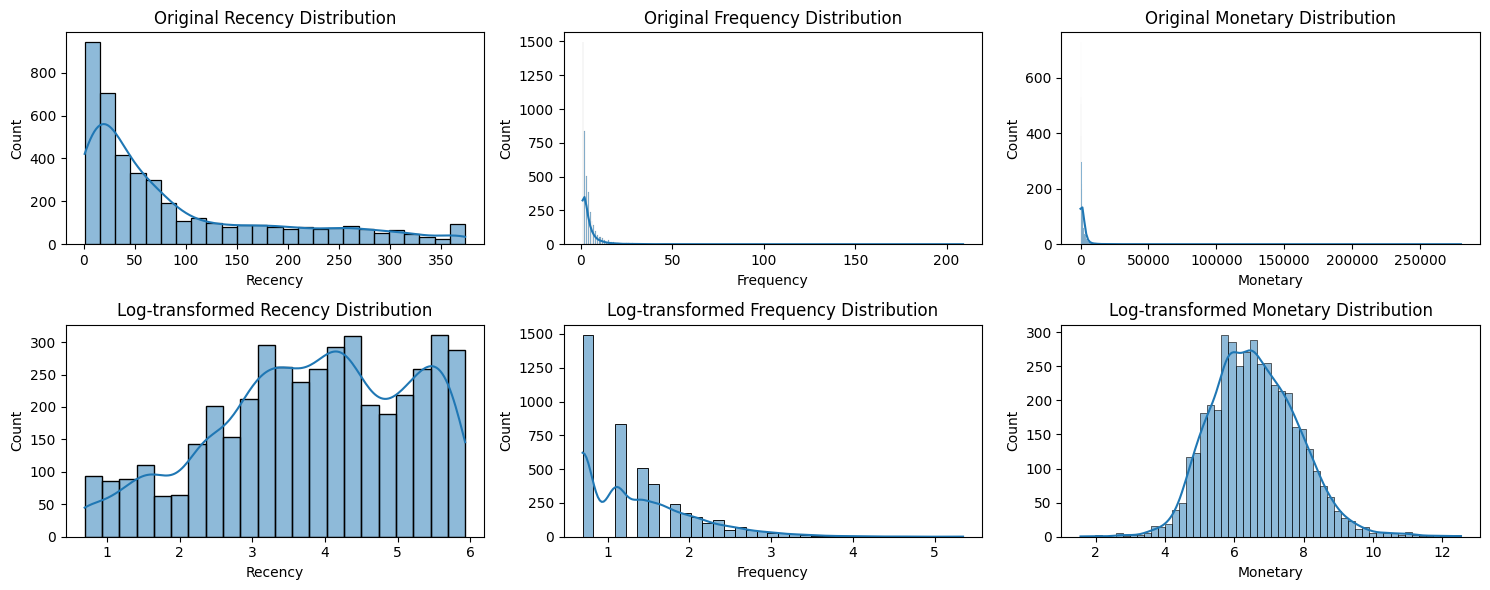

In [ ]:
# Apply log transformation to Recency, Frequency, and Monetary features to reduce skewness
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

print("RFM features transformed using log1p successfully.")
print("\nFirst 5 rows of the log-transformed RFM DataFrame:")
print(rfm_log.head())

# Visualize the distribution before and after transformation
plt.figure(figsize=(15, 6))

# Original distributions
plt.subplot(2, 3, 1)
sns.histplot(rfm['Recency'], kde=True)
plt.title('Original Recency Distribution')

plt.subplot(2, 3, 2)
sns.histplot(rfm['Frequency'], kde=True)
plt.title('Original Frequency Distribution')

plt.subplot(2, 3, 3)
sns.histplot(rfm['Monetary'], kde=True)
plt.title('Original Monetary Distribution')

# Log-transformed distributions
plt.subplot(2, 3, 4)
sns.histplot(rfm_log['Recency'], kde=True)
plt.title('Log-transformed Recency Distribution')

plt.subplot(2, 3, 5)
sns.histplot(rfm_log['Frequency'], kde=True)
plt.title('Log-transformed Frequency Distribution')

plt.subplot(2, 3, 6)
sns.histplot(rfm_log['Monetary'], kde=True)
plt.title('Log-transformed Monetary Distribution')

plt.tight_layout()
plt.show()

### 19. Feature Scaling - StandardScaler

Clustering algorithms like K-Means are distance-based, meaning they are sensitive to the magnitude of the features. If features have different scales, features with larger values might disproportionately influence the clustering results. To prevent this, we will standardize the RFM features using `StandardScaler`. This transforms the data to have a mean of 0 and a standard deviation of 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the log-transformed RFM features
# We exclude 'CustomerID' as it's an identifier, not a feature for scaling
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

# Convert the scaled array back to a DataFrame
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])

print("RFM features scaled successfully using StandardScaler.")
print("\nFirst 5 rows of the scaled RFM DataFrame:")
print(rfm_scaled.head())

# Optionally, add CustomerID back to the scaled DataFrame for later merging if needed
rfm_scaled_df = pd.concat([rfm_log['CustomerID'], rfm_scaled], axis=1)

print("\nFirst 5 rows of the combined CustomerID and scaled RFM DataFrame:")
print(rfm_scaled_df.head())

RFM features scaled successfully using StandardScaler.

First 5 rows of the scaled RFM DataFrame:
   Recency_scaled  Frequency_scaled  Monetary_scaled
0        1.461993         -0.955214         3.706225
1       -2.038734          1.074425         1.411843
2        0.373104          0.386304         0.716489
3       -0.623086         -0.955214         0.698739
4        1.424558         -0.955214        -0.618962

First 5 rows of the combined CustomerID and scaled RFM DataFrame:
   CustomerID  Recency_scaled  Frequency_scaled  Monetary_scaled
0       12346        1.461993         -0.955214         3.706225
1       12347       -2.038734          1.074425         1.411843
2       12348        0.373104          0.386304         0.716489
3       12349       -0.623086         -0.955214         0.698739
4       12350        1.424558         -0.955214        -0.618962


### 20. Determine Optimal Clusters (Elbow Method)

The Elbow Method is a heuristic used in K-Means clustering to determine the optimal number of clusters. It involves plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters (k). WCSS is the sum of the squared distances between each point and the centroid in a cluster. As the number of clusters increases, WCSS generally decreases. The 'elbow' point on the plot, where the rate of decrease sharply changes, is often considered the optimal number of clusters.

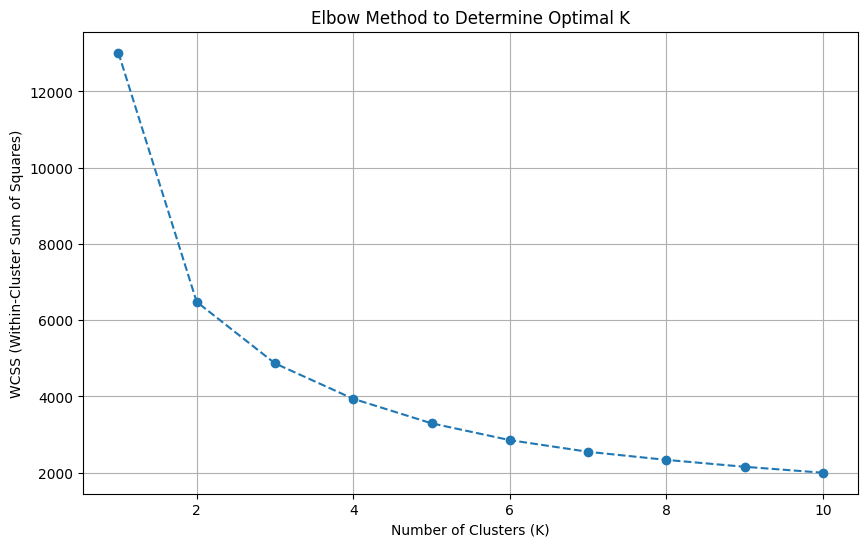

Elbow method plot generated. Look for the 'elbow' point to determine the optimal number of clusters.


In [ ]:
from sklearn.cluster import KMeans

# Prepare the data for clustering (using only the scaled RFM features)
X = rfm_scaled_df[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']]

wcss = []
# Test a range of k values (e.g., from 1 to 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init=10 for robustness
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

print("Elbow method plot generated. Look for the 'elbow' point to determine the optimal number of clusters.")

### 21. Apply K-Means Clustering

Based on the Elbow Method, we will choose an optimal number of clusters. Although the 'elbow' can sometimes be subjective, **k=3** appears to be a reasonable choice as it marks a point where the marginal gain from increasing the number of clusters significantly diminishes. This will allow us to create a manageable yet insightful number of customer segments.

Now, we will apply the K-Means algorithm using the chosen number of clusters to our scaled RFM features.

In [ ]:
# Initialize and fit K-Means with the optimal number of clusters (e.g., k=3)
optimal_k = 3 # Based on the Elbow Method plot
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X)

# Add the cluster labels to the rfm_scaled_df DataFrame
rfm_scaled_df['Cluster'] = kmeans.labels_

print(f"K-Means clustering applied with {optimal_k} clusters.")
print("First 5 rows of rfm_scaled_df with new 'Cluster' column:")
print(rfm_scaled_df.head())

K-Means clustering applied with 3 clusters.
First 5 rows of rfm_scaled_df with new 'Cluster' column:
   CustomerID  Recency_scaled  Frequency_scaled  Monetary_scaled  Cluster
0       12346        1.461993         -0.955214         3.706225        2
1       12347       -2.038734          1.074425         1.411843        0
2       12348        0.373104          0.386304         0.716489        2
3       12349       -0.623086         -0.955214         0.698739        2
4       12350        1.424558         -0.955214        -0.618962        1


### 22. Profile Customer Clusters

After assigning each customer to a cluster, the next step is to understand the characteristics of these clusters. We will do this by merging the cluster labels back to our original (unscaled) RFM DataFrame and then analyzing the average Recency, Frequency, and Monetary values for each cluster. This will help us to describe and name each customer segment.

Cluster Profiles (Mean RFM values):
         Recency  Frequency  Monetary
Cluster                              
0          17.06      13.34   7905.44
1         167.36       1.35    362.54
2          44.21       3.38   1265.06


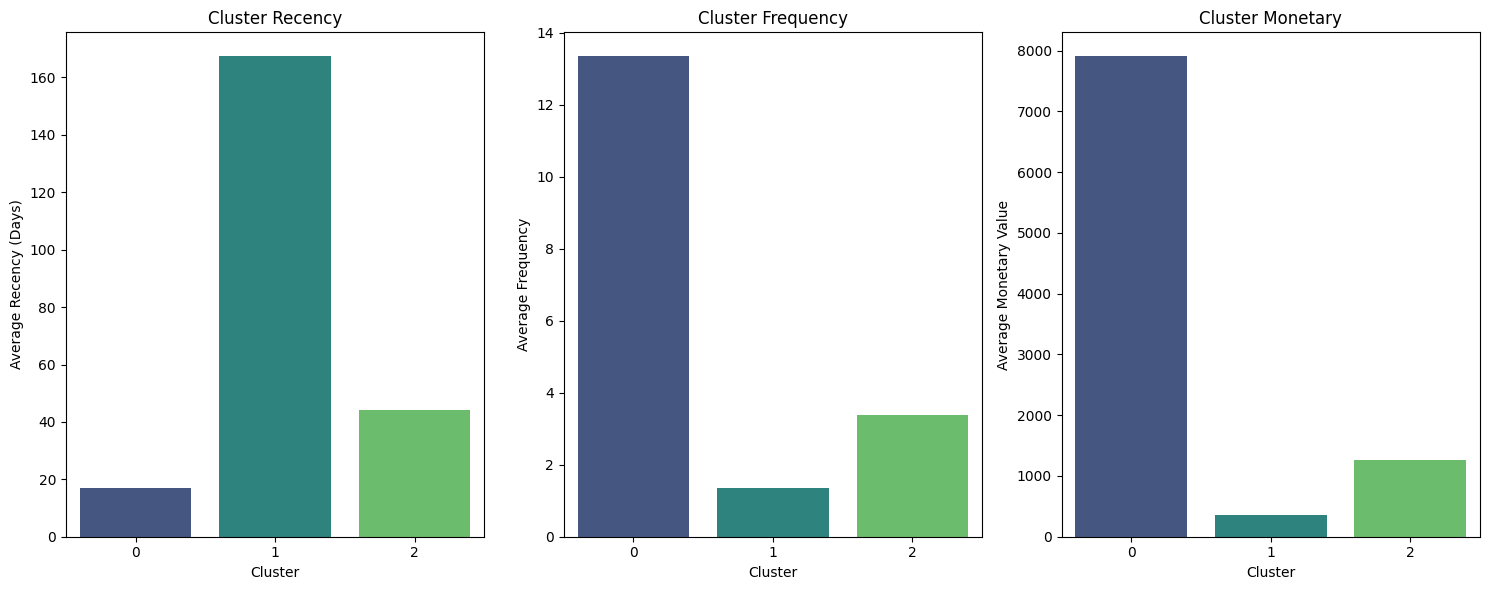

Bar plots generated to visualize cluster profiles.


In [ ]:
# Merge cluster labels back to the original RFM DataFrame
rfm_with_clusters = rfm.merge(rfm_scaled_df[['CustomerID', 'Cluster']], on='CustomerID')

# Calculate the mean of Recency, Frequency, and Monetary for each cluster
cluster_profiles = rfm_with_clusters.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

print("Cluster Profiles (Mean RFM values):")
print(cluster_profiles)

# Visualize the cluster profiles
plt.figure(figsize=(15, 6))

# Recency profile
plt.subplot(1, 3, 1)
sns.barplot(x=cluster_profiles.index, y='Recency', data=cluster_profiles, palette='viridis')
plt.title('Cluster Recency')
plt.ylabel('Average Recency (Days)')

# Frequency profile
plt.subplot(1, 3, 2)
sns.barplot(x=cluster_profiles.index, y='Frequency', data=cluster_profiles, palette='viridis')
plt.title('Cluster Frequency')
plt.ylabel('Average Frequency')

# Monetary profile
plt.subplot(1, 3, 3)
sns.barplot(x=cluster_profiles.index, y='Monetary', data=cluster_profiles, palette='viridis')
plt.title('Cluster Monetary')
plt.ylabel('Average Monetary Value')

plt.tight_layout()
plt.show()

print("Bar plots generated to visualize cluster profiles.")

### 23. Interpret and Name Customer Segments

Now that we have the average RFM values for each cluster, we can interpret their characteristics and assign meaningful names. This step is crucial for transforming raw data into actionable business insights.

Let's analyze the `cluster_profiles`:

*   **Cluster 0:**
    *   **Recency (17.06 days):** Very low, indicating recent purchases.
    *   **Frequency (13.34):** Very high, indicating frequent purchases.
    *   **Monetary (7905.44):** Very high, indicating high spending.
    *   **Interpretation:** These are our **'Best Customers'** or **'Champions'**. They buy recently, frequently, and spend a lot. They are likely loyal and highly valuable.

*   **Cluster 1:**
    *   **Recency (167.36 days):** Very high, indicating they haven't purchased in a long time.
    *   **Frequency (1.35):** Very low, indicating infrequent purchases.
    *   **Monetary (362.54):** Low, indicating low spending.
    *   **Interpretation:** These are our **'Churned'** or **'At-Risk'** customers. They bought long ago, infrequently, and spent little. They might be lost customers or those who only made a single, small purchase.

*   **Cluster 2:**
    *   **Recency (44.21 days):** Moderate, indicating relatively recent purchases, but not as recent as Cluster 0.
    *   **Frequency (3.38):** Moderate, indicating average purchase frequency.
    *   **Monetary (1265.06):** Moderate, indicating average spending.
    *   **Interpretation:** These are our **'Loyal Customers'** or **'Potential Loyalists'**. They are still active, buy somewhat frequently, and spend a good amount, but not at the level of the 'Champions'. They have potential for growth.

### 24. Marketing Recommendations

Based on the identified customer segments, here are tailored marketing strategies:

*   **Cluster 0: Champions / Best Customers**
    *   **Strategy:** Retain and reward them. These are your most valuable customers.
    *   **Actions:** Implement loyalty programs, offer exclusive previews of new products, provide personalized recommendations, solicit feedback for product development, and encourage referrals.

*   **Cluster 1: Churned / At-Risk Customers**
    *   **Strategy:** Re-engage them. Try to win them back.
    *   **Actions:** Send targeted win-back campaigns with special discounts or incentives, offer personalized product suggestions based on past purchases, conduct surveys to understand why they stopped purchasing, or introduce them to new product lines.

*   **Cluster 2: Loyal Customers / Potential Loyalists**
    *   **Strategy:** Nurture and upsell them to become 'Champions'.
    *   **Actions:** Encourage more frequent purchases with personalized promotions, recommend higher-value items, offer bundle deals, send regular newsletters with relevant content, and provide excellent customer service to build stronger relationships.

### 25. Conclusion

This customer segmentation project successfully identified three distinct customer segments using RFM analysis and K-Means clustering:

1.  **Champions:** Highly valuable, recent, frequent, and high-spending customers.
2.  **Churned/At-Risk:** Customers who have not purchased recently, buy infrequently, and spend little.
3.  **Loyal Customers/Potential Loyalists:** Active customers with moderate recency, frequency, and monetary values.

By understanding these segments, the online retail business can develop more effective and targeted marketing strategies, leading to improved customer satisfaction, retention, and ultimately, increased revenue. The insights gained from this analysis provide a solid foundation for data-driven decision-making in marketing and business development.